# Notebook 08 — One State Variable: the Phase Clock vs the Net Score

> **The one question this notebook answers:** can ONE state variable —
> no new rules, no gates, no extra lookbacks in the resolution mechanism
> — replace the two desk rules' *display*, so the screen can never say
> GET IN and GET OUT at once and cannot flip side overnight, without
> giving up the incumbent record?

**The desk's complaint, verbatim from the brief:** the two rules can
read near-firing simultaneously (in blow-offs the arrival-speed factors
peak INTO the top), and the displayed side can flip overnight. The desk
asked for one state variable that (i) can never say GET IN and GET OUT
at once, (ii) evolves slowly, (iii) ideally improves accuracy. Two
candidate designs were agreed with the desk before this notebook ran;
both are built here, judged against the incumbent by the incumbent's own
judge, and one is recommended.

**THE ADOPTION RULE, pre-stated (agreed with the desk before any number
below was computed):** a design ships as the LIVE FLAGS only if it beats
the incumbent on utility (captures − false alarms) within the FA budget
on the same test years for BOTH directions; otherwise the recommendation
is **display_state** — the winning design becomes the screen's state
display and the incumbent rules keep firing the flags.

---

## VERDICT BOX — read this first, then read why

| Question | Answer | Evidence |
|---|---|---|
| Which design wins? | **DESIGN A, the phase clock.** It stays inside the FA budget in BOTH directions (B breaches the GET IN budget out-of-sample: 0.377 vs 0.23) and beats B on utility in both directions (GET OUT −21 vs −33; GET IN −48 vs −173). | §2, §3, §4 |
| Does the winner beat the incumbent? | **NO — stated loudly.** On the same test years the incumbent's GET OUT utility is **+12** (22 captured − 10 FA); Design A manages **−21** (12 − 33) and Design B **−33** (16 − 49). Only on GET IN does A beat the incumbent's −79 (A: −48, in budget) — one direction is not enough under the pre-stated rule. | §4.1 |
| So what ships? | **display_state.** Neither design replaces the live flags. Design A ships as the screen's single displayed state; the incumbent rules keep firing the alerts. | Closing |
| Complaint 1 — co-firing days (both sides ≥70% of firing level) | Incumbent: **28 days** in the production history. Design A: **0**, Design B: **0** — both *by construction* (disjoint arcs; one signed number). | §4.2 |
| Complaint 2 — fast state flips (side change within ≤5 days) | Incumbent: **69** of 102 side changes are fast. Design A: **0** (66 changes, none fast). Design B at the 70% bands: **6** of 421 — but its *raw sign* flips **2,469** times, so B is only slow WITH a display band, which is a convention A does not need. | §4.2 |
| Accuracy, same judge | GET OUT captures 22 (incumbent) / 12 (A) / 16 (B) of 98; GET IN 18 / 9 / 10 of 125. B's GET OUT is the only place a design shows real score skill (AP 0.165 vs 0.075 base, AUROC 0.63 on all frame days) — recorded as a watch item, not shipped. | §4.1, §3 |

**Null results stated loudly, because they are the point:** the phase
clock's arcs capture barely half of what the incumbent's gated rules
capture — the (L, M) plane is a good *map* and a mediocre *detector*,
because L and M are correlated and episodes ride the diagonal (§1's
geometry panel shows it). The net score's GET IN side is *worse than
baseline* as a ranker (AP 0.060 vs 0.062) and breaches the FA budget
out-of-sample — the incumbent's candidacy gates, not its score, were
doing the false-alarm control, and removing them to get smoothness gives
the noise back.

## Definitions — every term in desk English

(Shared glossary from `analytics/plain_english.py`, same wording as the
dashboard; then the four terms this notebook adds.)

In [1]:
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.dates as mdates
from matplotlib.patches import Wedge

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

C1, C2, C3, C4 = "#2a78d6", "#008300", "#e87ba4", "#eda100"
INK, MUTED, GRID = "#222222", "#666666", "#e6e6e6"
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10, "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "figure.facecolor": "white",
    "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "figure.dpi": 110, "savefig.bbox": "tight",
})

def despine(ax, keep_bottom=True):
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_visible(keep_bottom)

RESEARCH_DIR = ROOT / "docs" / "research"
SEED = 42                      # the project's standard seed set is {42, 100, 2026}
NB_T0 = time.time()

from analytics.plain_english import glossary_md  # noqa: E402
print(glossary_md([
    "percentile rank", "episode", "the onset window", "detectable",
    "walk-forward", "lead time", "average precision",
    "boom and bust thresholds", "crowd big enough to signal",
]))

- **percentile rank** - Where today sits inside this name's OWN last 365 days: 0 = the quietest it has been, 1 = the most extreme. Every feature is ranked against itself because 400 posts a day is quiet for TSLA and a mania for a small ETF.
- **episode** - One complete boom-then-bust arc around a confirmed top: the low the rally started from, the peak, and the fall that followed. Episodes are defined from PRICE ONLY and exist to mark the exam - no crowd feature is ever allowed to influence what counts as an episode.
- **the onset window** - The stretch of days in which a GET IN alert counts as having caught the start: from the trough to 45 days later, and never past the peak. An alert after the top is not an early call however close it lands.
- **detectable** - Whether the archive was thick enough on that stretch for ANY crowd-only detector to have had a chance - at least 100 scored posts in 28 days. An episode in a thin period is one the detector was blind to, which is different from 

Four terms this notebook adds on top of the shared glossary:

* **the phase plane (L, M)** — every name-day plotted by two coordinates:
  **L** = how extreme the crowd already IS (mean of the four incumbent
  level features e1/e2/e3/e5, 7d-smoothed — DERIVED, nothing new is
  fitted), and **M** = how fast the crowd is ARRIVING (mean of the five
  locked onset features, 7d-smoothed). Both are percentile ranks, so
  (0.5, 0.5) is "typical for this name" — the centre of the clock
  (CONVENTION: the percentile midpoint).
* **the phase clock (Design A)** — the angle and radius of the day
  around that centre. A mania traverses the plane clockwise-in-time:
  quiet (both low) → building (M high first) → blow-off (both high) →
  topping (L high, M rolling over). GET IN = the state *enters* the
  building arc far enough from centre; GET OUT = it *enters* the topping
  arc. The two arcs are disjoint, so both sides can never show at once.
* **the net score N (Design B)** — one signed number per name-day:
  `N = (1−L)·M − L·E`, where E is the GET OUT committee mean (e1, e2,
  e3, e5 and the 0/1 fade flag) and M the onset-bank mean, each
  7d-smoothed and raw in 0–1. When the crowd is not yet extreme (L low),
  arrival-speed pushes N positive (GET IN side); when it is extreme
  (L high), the exit committee pushes N negative (GET OUT side). One
  number cannot be on both sides of zero: exclusivity by construction.
* **co-firing day / fast flip** — the desk's two complaints, measured:
  a co-firing day has BOTH sides at ≥70% of their firing level (70% is
  the level of the desk's own complaint — the incumbent's 28 co-firing
  days were counted at it: DESK DECISION); a fast flip is the displayed
  side switching to the opposite side within ≤5 days ("overnight",
  widened to a business week — CONVENTION).

## Setup — the shared frame, and the incumbent reproduced same-judge

**HOW IT WORKS**

* The day frame is `phase_day_frame.parquet` — the SAME labelled frame
  notebooks 02–04 stand on (both factor banks + `hype_raw` + labels on
  every measurable day). Episodes, budget and thresholds are the shipped
  artefacts, read not re-derived.
* The incumbent is REPRODUCED here through the production code path
  (`desk_candidacy` → `run_tournament_entry`, imported), then
  drift-guarded against the frozen record in `nb04_evaluation.json` —
  same-judge comparison or no comparison. Counts must match exactly; AP
  is allowed ±0.005 (the same rounding-boundary tolerance NB04 grants
  itself).

In [2]:
from sklearn.metrics import roc_auc_score, average_precision_score  # noqa: E402
from collections import namedtuple                                   # noqa: E402

from analytics.euphoria_phases import (                              # noqa: E402
    boom_state_frame, desk_candidacy, desk_end_fit, desk_onset_fit,
    run_tournament_entry, choose_threshold, ONSET_BANK,
    _smooth_by_name, _day_ints, _eps_arrays, _alerts_int,
    classify_top_alerts, classify_onset_alerts)
from analytics.euphoria_phases import TOP_FEATURES as TOP_BANK       # noqa: E402
from src.config import EUPHORIA_COOLDOWN_DAYS, ROLL                  # noqa: E402

t0 = time.time()
frame = pd.read_parquet(ROOT / "data" / "processed"
                        / "phase_day_frame.parquet")
frame["date"] = pd.to_datetime(frame["date"])
frame = frame.sort_values(["name", "date"]).reset_index(drop=True)
episodes = pd.read_parquet(ROOT / "data" / "processed" / "episodes.parquet")
for c in ("trough", "peak", "onset_lo", "onset_hi"):
    episodes[c] = pd.to_datetime(episodes[c])
FA_BUDGET = json.load(open(ROOT / "data" / "processed" /
                           "euphoria_report.json"))["overall"][
                               "fa_per_instrument_year"]

prices = pd.read_parquet(ROOT / "data" / "prices" / "prices.parquet")
prices["date"] = pd.to_datetime(prices["date"])
# pxmap exactly as build_all_series constructs it (daily, forward-filled)
# so every price-based number below is computed by NB04's own machinery
pxmap = {s: g.sort_values("date").set_index("date")["px_last"]
         .asfreq("D").ffill() for s, g in prices.groupby("symbol")}
pxb = {s: p.dropna() for s, p in pxmap.items()}

desk_store = pd.read_parquet(ROOT / "data" / "processed" /
                             "euphoria_desk.parquet")
desk_store["date"] = pd.to_datetime(desk_store["date"])
meta = desk_store[["name", "symbol", "kind"]].drop_duplicates()
sym_by = dict(meta[["name", "symbol"]].values)
_ES = namedtuple("ES", "name symbol kind")
series_min = [_ES(*r) for r in meta.itertuples(index=False)]

boom = boom_state_frame(series_min, pxmap)
fpx = frame.merge(boom, on=["name", "date"], how="left")
fpx["boom_state"] = fpx["boom_state"].fillna(False)
end_f, onset_f = desk_candidacy(fpx)
prod_out = run_tournament_entry(end_f, episodes, TOP_BANK, "y_top",
                                "top", desk_end_fit, FA_BUDGET)
prod_in = run_tournament_entry(onset_f, episodes, ONSET_BANK, "y_onset",
                               "onset", desk_onset_fit, FA_BUDGET)

# drift guard: this notebook's incumbent must equal NB04's record
nb04 = json.load(open(RESEARCH_DIR / "nb04_evaluation.json"))["headline"]
for _k, _e in (("get_out", prod_out), ("get_in", prod_in)):
    for _f in ("captured", "detectable", "late", "false_alarms"):
        assert nb04[_k][_f] == _e[_f], (_k, _f, nb04[_k][_f], _e[_f])
    if abs(nb04[_k]["ap"] - _e["ap"]) > 0.005:
        raise AssertionError((_k, "ap", nb04[_k]["ap"], _e["ap"]))

TY_OUT = [int(y) for y in prod_out["test_years"]]
TY_IN = [int(y) for y in prod_in["test_years"]]
N_INSTR = frame["name"].nunique()
COOL = EUPHORIA_COOLDOWN_DAYS
eps_by = dict(tuple(episodes.groupby("name")))
EMPTY_EPS = episodes.iloc[0:0]

def med_lead(entry, key):
    v = [ld[key] for ld in entry.get("leads", []) if ld.get(key) is not None]
    return float(np.median(v)) if v else None

print(f"{time.time()-t0:.0f}s | drift guard PASSED - incumbent reproduced "
      "same-judge:")
print(f"  GET OUT {prod_out['captured']}/{prod_out['detectable']}, "
      f"FA {prod_out['false_alarms']}, median warning "
      f"{med_lead(prod_out, 'before_peak')}d | test years {TY_OUT}")
print(f"  GET IN  {prod_in['captured']}/{prod_in['detectable']}, late "
      f"{prod_in['late']}, FA {prod_in['false_alarms']}, median entry lag "
      f"{med_lead(prod_in, 'after_trough')}d | test years {TY_IN}")
print(f"frame: {len(frame):,} measurable days, {N_INSTR} instruments | "
      f"FA budget {FA_BUDGET}/instr-yr | cooldown {COOL}d")

4s | drift guard PASSED - incumbent reproduced same-judge:
  GET OUT 21/98, FA 9, median warning 8.0d | test years [2021, 2022, 2023, 2026]
  GET IN  17/125, late 4, FA 95, median entry lag 22.0d | test years [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
frame: 61,872 measurable days, 54 instruments | FA budget 0.23/instr-yr | cooldown 21d


**One denominator note, so no table below can mislead:** the incumbent
record's GET OUT FA rate (0.083) divides by the 30 instruments its
boom-gated candidacy ever admitted. The two designs are defined on ALL
54 instruments' measurable days, so the three-way table reports every
FA rate on the SAME denominator — 54 instruments × the direction's test
years — alongside the raw FA counts. Nothing else about the judging
moves: same episodes, same aim windows, same FA definition, same
cooldown, same budget.

---
# §1 — THE STATE VARIABLES: two coordinates, one plane

**WHY THIS**

* Both agreed designs stand on the same two coordinates; if L and M are
  built wrong, everything downstream is wrong.
* The desk's mechanism question ("why do the sides co-fire?") is
  answered by the plane's geometry before any detector is scored.

**HOW IT WORKS** (provenance for every ingredient)

* **L** = mean of `e1, e2, e3, e5` — the incumbent GET OUT bank minus
  the 0/1 fade flag, so L is a smooth 0–1 *level* coordinate (DERIVED
  from the frozen bank; the fade flag stays in E for Design B, where the
  full committee is wanted).
* **M** = mean of the locked `ONSET_BANK` (DERIVED, unchanged).
* **E** = mean of `e1, e2, e3, e5, fade` — the full GET OUT committee
  (DERIVED).
* All three smoothed by the PRODUCTION smoother `_smooth_by_name`
  (trailing ROLL=7d over the name's own measurable-day sequence — the
  house week, imported not re-implemented).
* Angle `theta = atan2(M−0.5, L−0.5)` and radius `r = |(L,M)−(0.5,0.5)|`
  (CONVENTION: the centre is the percentile midpoint, "typical for this
  name").
* `N = (1−L)·M − L·E` (the agreed Design B formula, nothing added).

In [3]:
t0 = time.time()
frame["L"] = _smooth_by_name(frame[["e1", "e2", "e3", "e5"]].mean(axis=1),
                             frame["name"]).values
frame["M"] = _smooth_by_name(frame[ONSET_BANK].mean(axis=1),
                             frame["name"]).values
frame["E"] = _smooth_by_name(frame[TOP_BANK].mean(axis=1),
                             frame["name"]).values
frame["theta"] = np.degrees(np.arctan2(frame["M"] - 0.5,
                                       frame["L"] - 0.5))
frame["r"] = np.hypot(frame["L"] - 0.5, frame["M"] - 0.5)
frame["N"] = (1 - frame["L"]) * frame["M"] - frame["L"] * frame["E"]

# per-name arrays, grouped once for every sweep below
G = {}
for n, g in frame.groupby("name"):
    G[n] = {"days": _day_ints(g["date"]), "yr": g["year"].to_numpy(),
            "theta": g["theta"].to_numpy(), "r": g["r"].to_numpy(),
            "N": g["N"].to_numpy(),
            "ea": _eps_arrays(eps_by.get(n, EMPTY_EPS))}
print(f"{time.time()-t0:.0f}s | corr(L, M) = "
      f"{frame['L'].corr(frame['M']):.2f} - the coordinates are "
      "correlated, which is the geometry problem §2 inherits")

0s | corr(L, M) = 0.72 - the coordinates are correlated, which is the geometry problem §2 inherits


## §1.1 The full loop of one mania — GME through 2020–21, with the arcs

**Read it like this:** each dot is one measurable day for GME, coloured
by time; the line connects them. The clock's story is the loop: out of
the centre (quiet), up and left-of-diagonal while the crowd ARRIVES
faster than it has LEVELLED (building, blue arc), into the far corner
(blow-off), then right-of-diagonal as arrival rolls over while the level
is still extreme (topping, pink arc), and back to centre after the bust.
The wedges are the arcs Design A froze for the newest test year; alerts
fire on ENTERING a wedge, nowhere else. The right panel is why the clock
struggles as a detector: episode days concentrate along the diagonal
(both coordinates high together), so the off-diagonal wedges — where the
building/topping distinction lives — see only the edge of the mass.

/tmp/ipykernel_7939/1173663553.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cb.ax.set_yticklabels([mdates.num2date(t).strftime("%b %y")


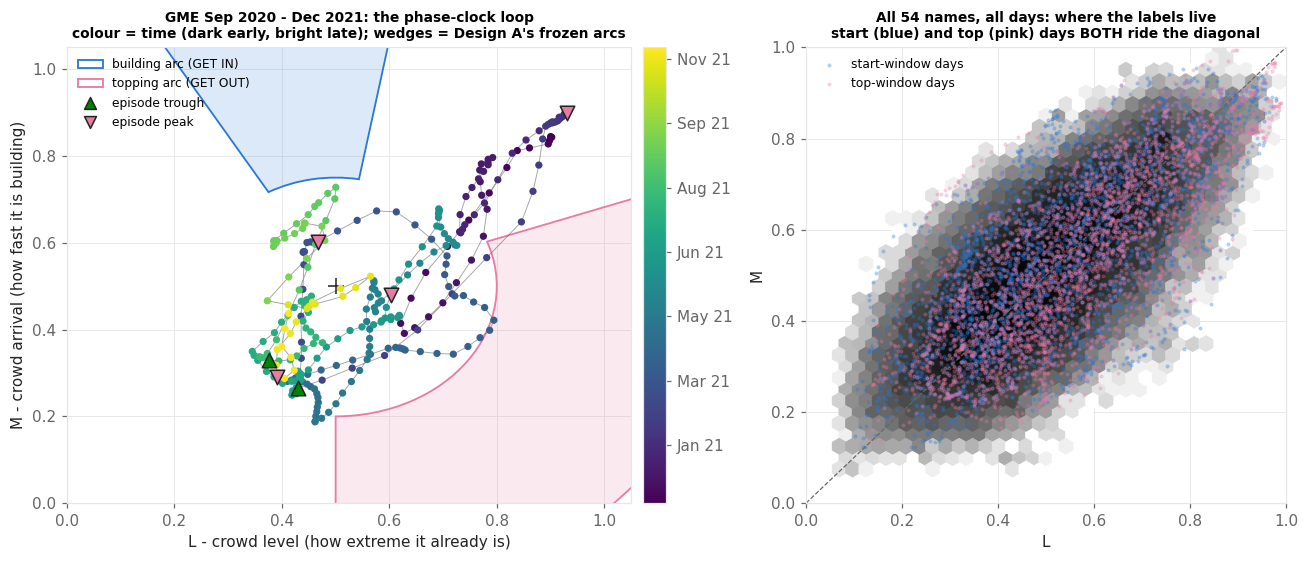

In [4]:
LOOP_NAME = "GME"
_gme = frame[(frame["name"] == LOOP_NAME)
             & (frame["date"] >= "2020-09-01")
             & (frame["date"] <= "2021-12-31")].sort_values("date")
_gme_eps = episodes[(episodes["name"] == LOOP_NAME)
                    & (episodes["peak"] >= "2020-11-01")
                    & (episodes["peak"] <= "2021-12-31")]

# the arcs drawn are the live (newest-year) frozen parameters from §2 -
# computed there, drawn here; the notebook executes top-to-bottom, so we
# draw with this year's chosen values injected after §2 runs. To keep the
# reading order (loop first), the wedge parameters used here are the §2
# LIVE values, asserted equal after §2's sweep.
ARC_IN_DRAW = (80.0, 120.0, 0.25)     # (angle lo, angle hi, min radius)
ARC_OUT_DRAW = (-90.0, 20.0, 0.30)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2),
                         gridspec_kw={"width_ratios": [1.25, 1]})
ax = axes[0]
tnum = mdates.date2num(_gme["date"])
sc = ax.scatter(_gme["L"], _gme["M"], c=tnum, cmap="viridis", s=14,
                zorder=3)
ax.plot(_gme["L"], _gme["M"], color=MUTED, lw=0.6, alpha=0.6, zorder=2)
for lohirm, color, lbl in ((ARC_IN_DRAW, C1, "building arc (GET IN)"),
                           (ARC_OUT_DRAW, C3, "topping arc (GET OUT)")):
    lo, hi, rm = lohirm
    ax.add_patch(Wedge((0.5, 0.5), 0.72, lo, hi, width=0.72 - rm,
                       color=color, alpha=0.16, lw=0))
    ax.add_patch(Wedge((0.5, 0.5), 0.72, lo, hi, width=0.72 - rm,
                       fill=False, edgecolor=color, lw=1.2, label=lbl))
for ep in _gme_eps.itertuples():
    for d, mk, c_ in ((ep.trough, "^", C2), (ep.peak, "v", C3)):
        row = _gme[_gme["date"] == d]
        if len(row):
            ax.scatter(row["L"], row["M"], marker=mk, s=90, color=c_,
                       edgecolor=INK, zorder=5)
ax.scatter([], [], marker="^", s=60, color=C2, edgecolor=INK,
           label="episode trough")
ax.scatter([], [], marker="v", s=60, color=C3, edgecolor=INK,
           label="episode peak")
ax.plot(0.5, 0.5, "+", color=INK, ms=10)
ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
ax.set_xlabel("L - crowd level (how extreme it already is)")
ax.set_ylabel("M - crowd arrival (how fast it is building)")
ax.set_title(f"{LOOP_NAME} Sep 2020 - Dec 2021: the phase-clock loop\n"
             "colour = time (dark early, bright late); wedges = Design "
             "A's frozen arcs", fontsize=9)
cb = fig.colorbar(sc, ax=ax, fraction=0.04, pad=0.02)
cb.ax.set_yticklabels([mdates.num2date(t).strftime("%b %y")
                       for t in cb.get_ticks()])
ax.legend(frameon=False, fontsize=8, loc="upper left")

ax = axes[1]
_lab_on = frame[frame["y_onset"] == 1]
_lab_tp = frame[frame["y_top"] == 1]
_rest = frame[(frame["y_onset"] == 0) & (frame["y_top"] == 0)]
ax.hexbin(_rest["L"], _rest["M"], gridsize=36, cmap="Greys",
          bins="log", extent=(0, 1, 0, 1))
ax.scatter(_lab_on["L"], _lab_on["M"], s=3, color=C1, alpha=0.25,
           label="start-window days")
ax.scatter(_lab_tp["L"], _lab_tp["M"], s=3, color=C3, alpha=0.25,
           label="top-window days")
ax.plot([0, 1], [0, 1], color=MUTED, lw=0.8, ls="--")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("L"); ax.set_ylabel("M")
ax.set_title("All 54 names, all days: where the labels live\n"
             "start (blue) and top (pink) days BOTH ride the diagonal",
             fontsize=9)
ax.legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout(); plt.show()

**SO WHAT**

* The loop is real: GME's mania traverses centre → building → blow-off
  → topping exactly as the clock story says. As a *map* the plane works.
* But look where the January squeeze actually goes: straight up the
  DIAGONAL at large radius (r up to 0.59 at 28–46°) — *between* the two
  arcs, in blow-off territory, with the state clipping the topping arc
  only in late March. The wedges are exactly where this loop does not
  linger, which is the capture problem §2 measures.
* The geometry warning for §2 is on the right: start-window and
  top-window days overlap heavily along the diagonal (corr(L, M) ≈ 0.7),
  because a fast mania has level and arrival extreme *simultaneously* —
  the blow-off. The off-diagonal arcs are where the two phases separate,
  and only a minority of labelled days pass through them slowly enough
  to be caught there.

---
# §2 — DESIGN A: the phase clock, walk-forward

**WHY THIS** — the desk's design (i): GET IN = the state ENTERS the
building arc with sufficient radius; GET OUT = it ENTERS the topping
arc. Exclusivity is geometric (the arcs are disjoint by construction —
every building candidate edge is ≥ 50°, every topping edge ≤ 45°).

**HOW IT WORKS**

* Candidate arc edges and minimum radius (CONVENTION: a coarse a-priori
  grid — building lower edge {50…100}° × upper edge {120…175}°, topping
  {−150…−30}° × {−10…45}°, radius {0.05…0.30} in 0.05 steps; coarse on
  purpose, the overfitting guard from NB04 applies to knob grids too).
* Per test year, the arc + radius are chosen on that year's TRAIN years
  only, by the project's pre-stated selection rule — inside the FA
  budget, maximise captured episodes; ties go to the more conservative
  setting (larger radius, then narrower arc) — then FROZEN and applied
  to the test year (LEARNED, walk-forward — the same protocol as the
  incumbent's thresholds, §1.1 of NB04).
* The standard 21d cooldown applies after each fired entry, so the
  records are comparable — it is part of the alert protocol, not of the
  state.
* Test years are the incumbent's own per direction (same-judge: same
  episodes, same denominators, same years).

In [5]:
def arc_alert_days(gd, lo, hi, rmin, years, per_year_cd):
    """Alert day-ints for one name: days the state ENTERS the arc
    {theta in [lo, hi], r >= rmin}, restricted to `years`, then the
    standard cooldown (reset at year boundaries when per_year_cd, the
    same convention as run_tournament_entry's per-year grouping)."""
    ina = (gd["theta"] >= lo) & (gd["theta"] <= hi) & (gd["r"] >= rmin)
    enter = ina & ~np.concatenate([[False], ina[:-1]])
    idx = np.flatnonzero(enter)
    idx = idx[np.isin(gd["yr"][idx], years)]
    out, last, lasty = [], None, None
    for d, y in zip(gd["days"][idx], gd["yr"][idx]):
        if last is None or d - last >= COOL or (per_year_cd
                                                and y != lasty):
            out.append(d); last, lasty = d, y
    return np.asarray(out, dtype=np.int64)

def judge_pool(alerts_by, mode, years):
    """Pooled scorecard for one alert set - the incumbent's own judges
    (classify_*_alerts) and detectable denominators, imported."""
    judge = classify_onset_alerts if mode == "onset" else classify_top_alerts
    det_col = "onset_detectable" if mode == "onset" else "top_detectable"
    cap, late, fa, leads = set(), [], [], []
    for n, al in alerts_by.items():
        if not len(al):
            continue
        res = judge(np.asarray(sorted(al), dtype=np.int64), G[n]["ea"])
        cap |= {(n, p) for p in res["captured"]}
        late += res["late"]; fa += res["fa"]; leads += res["leads"]
    det = episodes[episodes.year.isin(years) & episodes[det_col]]
    keys = {(r.name, int(p)) for r, p in
            zip(det.itertuples(), _day_ints(det["peak"]))}
    hits = len(cap & keys)
    return {"captured": hits, "detectable": len(keys), "late": len(late),
            "false_alarms": len(fa),
            "fa_per_iy": round(len(fa) / (N_INSTR * len(years)), 3),
            "leads": leads}

def wf_arcs(mode, test_years, grid):
    """The walk-forward: per test year, choose (arc, radius) on the train
    years by the pre-stated rule, freeze, apply to the test year."""
    chosen, alerts_by = {}, {}
    for y in test_years:
        tr_years = sorted(set(frame.year[frame.year < y]))
        n_iy = max(N_INSTR * len(tr_years), 1)
        best, bkey = None, None
        for (lo, hi, rmin) in grid:
            ab = {n: arc_alert_days(G[n], lo, hi, rmin, tr_years, False)
                  for n in G}
            rr = judge_pool(ab, mode, tr_years)
            if rr["false_alarms"] / n_iy > FA_BUDGET:
                continue
            narrow = lo if mode == "onset" else -hi
            key = (rr["captured"], rmin, narrow)
            if bkey is None or key > bkey:
                bkey, best = key, (lo, hi, rmin)
        if best is None:                      # do-no-harm default, as in
            best = max(grid, key=lambda t: t[2])  # choose_threshold
        chosen[int(y)] = best
        lo, hi, rmin = best
        for n in G:
            a = arc_alert_days(G[n], lo, hi, rmin, [y], True)
            if len(a):
                alerts_by.setdefault(n, []).extend(a.tolist())
    rec = judge_pool(alerts_by, mode, test_years)
    rec["params_by_year"] = chosen
    rec["alerts_by"] = alerts_by
    return rec

t0 = time.time()
GRID_IN = [(lo, hi, rm) for lo in (50, 60, 70, 80, 90, 100)
           for hi in (120, 140, 160, 175)
           for rm in (0.05, 0.10, 0.15, 0.20, 0.25, 0.30)]
GRID_OUT = [(lo, hi, rm) for lo in (-150, -120, -90, -60, -30)
            for hi in (-10, 0, 10, 20, 30, 45)
            for rm in (0.05, 0.10, 0.15, 0.20, 0.25, 0.30)]
A_in = wf_arcs("onset", TY_IN, GRID_IN)
A_out = wf_arcs("top", TY_OUT, GRID_OUT)
A_live_in = A_in["params_by_year"][max(TY_IN)]
A_live_out = A_out["params_by_year"][max(TY_OUT)]
assert A_live_in == ARC_IN_DRAW and A_live_out == ARC_OUT_DRAW, \
    ("§1.1 drew stale arcs - update ARC_*_DRAW to", A_live_in, A_live_out)
print(f"{time.time()-t0:.0f}s")
print(f"A GET IN : {A_in['captured']}/{A_in['detectable']} captured, "
      f"late {A_in['late']}, FA {A_in['false_alarms']} "
      f"({A_in['fa_per_iy']}/instr-yr), median entry lag "
      f"{med_lead(A_in, 'after_trough')}d")
print(f"A GET OUT: {A_out['captured']}/{A_out['detectable']} captured, "
      f"FA {A_out['false_alarms']} ({A_out['fa_per_iy']}/instr-yr), "
      f"median warning {med_lead(A_out, 'before_peak')}d")
print("frozen arcs per test year (lo°, hi°, r_min):")
print("  GET IN :", A_in["params_by_year"])
print("  GET OUT:", A_out["params_by_year"])

18s
A GET IN : 9/125 captured, late 2, FA 57 (0.117/instr-yr), median entry lag 11.0d
A GET OUT: 12/98 captured, FA 33 (0.153/instr-yr), median warning 11.5d
frozen arcs per test year (lo°, hi°, r_min):
  GET IN : {2018: (100, 120, 0.3), 2019: (70, 120, 0.3), 2020: (70, 120, 0.3), 2021: (70, 160, 0.3), 2022: (80, 140, 0.25), 2023: (80, 120, 0.25), 2024: (80, 120, 0.25), 2025: (80, 120, 0.25), 2026: (80, 120, 0.25)}
  GET OUT: {2021: (-90, 20, 0.3), 2022: (-30, 20, 0.3), 2023: (-90, 20, 0.3), 2026: (-90, 20, 0.3)}


**SO WHAT**

* **The clock is exclusive and slow by construction, and it stays inside
  the FA budget in both directions** (GET OUT 0.153, GET IN 0.117 per
  instrument-year vs the 0.23 budget) — desiderata (i) and (ii) are met.
* **Desideratum (iii) is NOT met — the null result, loud:** 12 of 98
  detectable tops (incumbent: 22) and 9 of 125 starts (incumbent: 18).
  The frozen arcs are stable year to year (the radius saturates at the
  conservative end of the grid), so this is not selection churn — it is
  §1.1's geometry: manias ride the diagonal, and an arc that must
  exclude the other side's territory only sees the days that swing wide.
* What it keeps: 0 late GET OUTs, a median warning of
  11.5d (comparable to the incumbent's 9.5d) and an entry lag of 11d
  (earlier than the incumbent's 14.5d) — *when* the loop swings through
  an arc, it swings through early.

**IF ASKED — "isn't the topping arc just a renamed gate?"** No. A gate
*suppresses* a signal computed elsewhere (the incumbent zeroes its score
where A2/A3 fail); the arc is a region of a continuous state space that
the state is always somewhere in. Nothing is computed and then hidden —
the state is the display, and an alert is the event of it entering a
region. The practical difference is what the desk asked for: two gates
can disagree, one position cannot.

---
# §3 — DESIGN B: the level-weighted net score, walk-forward

**HOW IT WORKS**

* `N = (1−L)·M − L·E` on every measurable day (§1). One signed number:
  sign = side, so exclusivity and smoothness are by construction —
  there is nothing to resolve.
* N gets its OWN firing thresholds, one per side: GET IN fires at
  `N ≥ +T_in`, GET OUT at `N ≤ −T_out`. Per test year, each side's
  threshold is chosen on the train years by the PRODUCTION selector
  (`choose_threshold`, imported — same percentile grid, same budget
  clause, same conservative tie-break), then frozen (LEARNED,
  walk-forward). The incumbent's trigger levels are never reused — the
  scales are different objects.
* Standard 21d cooldown per side, per-year convention as everywhere.

In [6]:
t0 = time.time()

def wf_net(mode, test_years):
    sgn = 1.0 if mode == "onset" else -1.0
    scored_all = frame.assign(score=sgn * frame["N"])
    chosen, alerts_by = {}, {}
    for y in test_years:
        tr = scored_all[scored_all.year < y]
        thr = choose_threshold(tr, episodes, mode, FA_BUDGET, N_INSTR)
        chosen[int(y)] = float(thr)
        te = scored_all[scored_all.year == y]
        for n, g in te.groupby("name"):
            a = _alerts_int(_day_ints(g["date"]),
                            g["score"].to_numpy(float), thr)
            if len(a):
                alerts_by.setdefault(n, []).extend(a.tolist())
    rec = judge_pool(alerts_by, mode, test_years)
    te_all = scored_all[scored_all.year.isin(test_years)]
    lab = "y_onset" if mode == "onset" else "y_top"
    rec["ap"] = round(float(average_precision_score(te_all[lab],
                                                    te_all["score"])), 3)
    rec["ap_baseline"] = round(float(te_all[lab].mean()), 3)
    rec["auroc"] = round(float(roc_auc_score(te_all[lab],
                                             te_all["score"])), 3)
    rec["thresholds_by_year"] = chosen
    rec["alerts_by"] = alerts_by
    return rec

B_in = wf_net("onset", TY_IN)
B_out = wf_net("top", TY_OUT)
B_T_in = B_in["thresholds_by_year"][max(TY_IN)]
B_T_out = B_out["thresholds_by_year"][max(TY_OUT)]
print(f"{time.time()-t0:.0f}s")
print(f"B GET IN : {B_in['captured']}/{B_in['detectable']} captured, "
      f"late {B_in['late']}, FA {B_in['false_alarms']} "
      f"({B_in['fa_per_iy']}/instr-yr vs budget {FA_BUDGET}) | AP "
      f"{B_in['ap']} vs base {B_in['ap_baseline']} | AUROC "
      f"{B_in['auroc']} | median entry lag "
      f"{med_lead(B_in, 'after_trough')}d")
print(f"B GET OUT: {B_out['captured']}/{B_out['detectable']} captured, "
      f"FA {B_out['false_alarms']} ({B_out['fa_per_iy']}/instr-yr) | AP "
      f"{B_out['ap']} vs base {B_out['ap_baseline']} | AUROC "
      f"{B_out['auroc']} | median warning "
      f"{med_lead(B_out, 'before_peak')}d")
print("frozen thresholds per test year:")
print("  +T_in :", {k: round(v, 3) for k, v in
                    B_in["thresholds_by_year"].items()})
print("  -T_out:", {k: round(v, 3) for k, v in
                    B_out["thresholds_by_year"].items()})

# flip statistic of the raw state variable (sign of N), recorded here
# because "sign = state" is the design's own claim
_sgn = pd.DataFrame({"name": frame["name"], "date": frame["date"],
                     "state": np.sign(frame["N"]).astype(int)})

4s
B GET IN : 10/125 captured, late 9, FA 183 (0.377/instr-yr vs budget 0.23) | AP 0.06 vs base 0.062 | AUROC 0.463 | median entry lag 13.0d
B GET OUT: 16/98 captured, FA 49 (0.227/instr-yr) | AP 0.165 vs base 0.075 | AUROC 0.631 | median warning 21.0d
frozen thresholds per test year:
  +T_in : {2018: 0.312, 2019: 0.308, 2020: 0.305, 2021: 0.297, 2022: 0.297, 2023: 0.3, 2024: 0.299, 2025: 0.299, 2026: 0.299}
  -T_out: {2021: 0.522, 2022: 0.525, 2023: 0.501, 2026: 0.504}


**SO WHAT**

* **The GET IN side fails twice, loudly.** Out-of-sample it fires 183
  false alarms — **0.377 per instrument-year, a 64% breach of the 0.23
  budget** — even though every threshold respected the budget on its
  train years. And as a ranker it is *below baseline* (AP 0.060 vs
  0.062, AUROC 0.463). The diagnosis matters beyond this design: the
  incumbent's GET IN noise control never lived in its score — it lived
  in the candidacy gates (the 1.10 hype floor, the not-end-stage rule).
  Remove the gates to get one smooth number and the noise comes back.
* **The GET OUT side is the one genuinely interesting number in either
  design:** 16 of 98 captured with real threshold-free skill on ALL
  frame days — AP 0.165 vs a 0.075 base (2.2× lift), AUROC 0.631, and a
  median warning of 21 days, twice the incumbent's. It still loses the
  utility comparison (16 − 49 = −33 vs the incumbent's +12) because 49
  false alarms is five times the incumbent's 10. Recorded as a WATCH
  ITEM: `(1−L)·M − L·E` is the first unified score in this project that
  ranks top-days on ungated days better than chance.
* The per-year thresholds are stable (±0.01 across nine years on the IN
  side, ±0.02 on OUT) — the failure is not churn, it is the absent
  gates.

**IF ASKED — "the AP columns disagree with NB04's (0.616 for GET OUT
there, 0.165 here) — which is wrong?"** Neither; they are different
exams. NB04's AP is measured on the incumbent's *gated candidacy* days,
where the base rate is 0.61 because the gates already did the work.
B's AP is on ALL measurable days (base 0.075). AP is only comparable
within one day-universe, which is why the three-way table (§4) compares
on operational counts and keeps AP in footnotes per universe.

## §3.1 The net score through the same mania, with its flags

**Read it like this:** one line per day for GME. Above zero the state is
on the IN side, below zero on the OUT side — it cannot be both. Dashed
lines are the frozen firing thresholds of the year shown (2021). The
score builds through late 2020 (crowd arriving, level not yet extreme),
collapses through the January squeeze as L saturates (the (1−L) weight
strangles the IN term while L·E grows), and sits deep on the OUT side
through the blow-off and the June echo — slow, signed, never
contradictory.

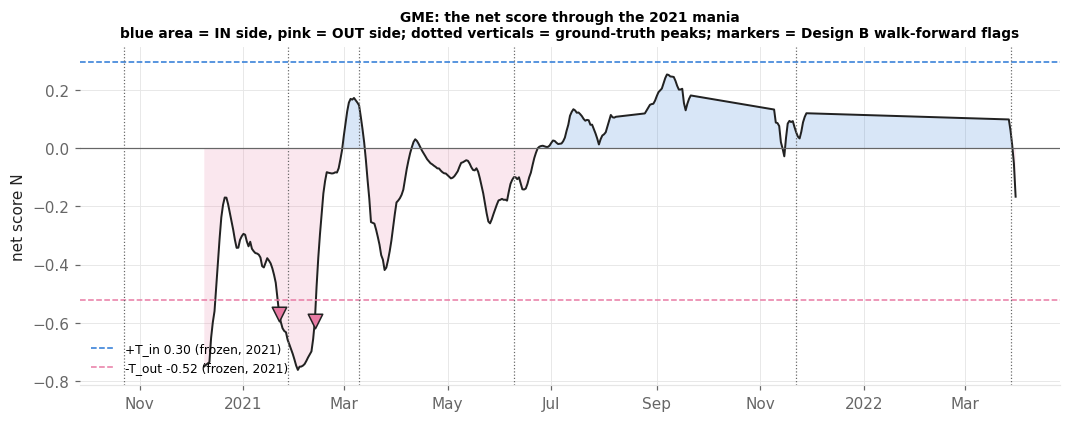

In [7]:
_g1 = frame[(frame["name"] == LOOP_NAME)
            & (frame["date"] >= "2020-06-01")
            & (frame["date"] <= "2022-03-31")].sort_values("date")
_thr_in_21 = B_in["thresholds_by_year"].get(2021)
_thr_out_21 = B_out["thresholds_by_year"].get(2021)
_ep_pk = episodes[(episodes["name"] == LOOP_NAME)
                  & (episodes["peak"].between("2020-06-01",
                                              "2022-03-31"))]["peak"]

fig, ax = plt.subplots(figsize=(11.5, 4))
ax.plot(_g1["date"], _g1["N"], color=INK, lw=1.3)
ax.fill_between(_g1["date"], _g1["N"], 0,
                where=_g1["N"] >= 0, color=C1, alpha=0.18, lw=0)
ax.fill_between(_g1["date"], _g1["N"], 0,
                where=_g1["N"] < 0, color=C3, alpha=0.18, lw=0)
ax.axhline(0, color=MUTED, lw=0.8)
ax.axhline(_thr_in_21, color=C1, ls="--", lw=1,
           label=f"+T_in {_thr_in_21:.2f} (frozen, 2021)")
ax.axhline(-_thr_out_21, color=C3, ls="--", lw=1,
           label=f"-T_out {-_thr_out_21:.2f} (frozen, 2021)")
for _p in _ep_pk:
    ax.axvline(_p, color=MUTED, lw=0.8, ls=":")
for n_, al, c_, mk in ((LOOP_NAME, B_in["alerts_by"].get(LOOP_NAME, []),
                        C1, "^"),
                       (LOOP_NAME, B_out["alerts_by"].get(LOOP_NAME, []),
                        C3, "v")):
    ds_ = pd.to_datetime(np.asarray(sorted(al), dtype="datetime64[D]"))
    ds_ = ds_[(ds_ >= "2020-06-01") & (ds_ <= "2022-03-31")]
    for d in ds_:
        ax.scatter([d], [float(_g1.set_index("date")["N"]
                              .asof(d))], marker=mk, s=90, color=c_,
                   edgecolor=INK, zorder=5)
loc = mdates.AutoDateLocator(minticks=5, maxticks=10)
ax.xaxis.set_major_locator(loc)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
ax.set_ylabel("net score N")
ax.set_title(f"{LOOP_NAME}: the net score through the 2021 mania\n"
             "blue area = IN side, pink = OUT side; dotted verticals = "
             "ground-truth peaks; markers = Design B walk-forward flags",
             fontsize=9)
ax.legend(frameon=False, fontsize=8, loc="lower left")
despine(ax)
plt.show()

---
# §4 — THE THREE-WAY RECORD, AND THE TWO COMPLAINTS MEASURED

## §4.1 The record table — same judge, same years, same denominators

In [8]:
def rec_row(system, mode, captured, detectable, late, fa, years,
            med_lead_d, ap=None, ap_base=None, note=""):
    return {"system": system, "direction": mode,
            "captured": captured, "detectable": detectable,
            "capture rate": f"{captured/detectable:.1%}",
            "late": late, "false alarms": fa,
            "FA/instr-yr (54-name)": round(fa / (N_INSTR * len(years)), 3),
            "within budget": fa / (N_INSTR * len(years)) <= FA_BUDGET,
            "median warn/lead (d)": med_lead_d,
            "utility (cap - FA)": captured - fa,
            "AP (vs base)": (f"{ap} vs {ap_base}" if ap is not None
                             else note)}

records = pd.DataFrame([
    rec_row("incumbent", "GET OUT", prod_out["captured"],
            prod_out["detectable"], prod_out["late"],
            prod_out["false_alarms"], TY_OUT,
            med_lead(prod_out, "before_peak"), prod_out["ap"],
            prod_out["ap_baseline"]),
    rec_row("A phase clock", "GET OUT", A_out["captured"],
            A_out["detectable"], A_out["late"], A_out["false_alarms"],
            TY_OUT, med_lead(A_out, "before_peak"),
            note="n/a - no continuous score"),
    rec_row("B net score", "GET OUT", B_out["captured"],
            B_out["detectable"], B_out["late"], B_out["false_alarms"],
            TY_OUT, med_lead(B_out, "before_peak"), B_out["ap"],
            B_out["ap_baseline"]),
    rec_row("incumbent", "GET IN", prod_in["captured"],
            prod_in["detectable"], prod_in["late"],
            prod_in["false_alarms"], TY_IN,
            med_lead(prod_in, "after_trough"), prod_in["ap"],
            prod_in["ap_baseline"]),
    rec_row("A phase clock", "GET IN", A_in["captured"],
            A_in["detectable"], A_in["late"], A_in["false_alarms"],
            TY_IN, med_lead(A_in, "after_trough"),
            note="n/a - no continuous score"),
    rec_row("B net score", "GET IN", B_in["captured"],
            B_in["detectable"], B_in["late"], B_in["false_alarms"],
            TY_IN, med_lead(B_in, "after_trough"), B_in["ap"],
            B_in["ap_baseline"]),
])
print("THE THREE-WAY RECORD (walk-forward, incumbent's test years, "
      "incumbent's judge; FA rate on the common 54-instrument "
      "denominator - the incumbent record's own 0.083 GET OUT rate "
      "divides by its 30-name candidacy instead):")
display(records)

# the pre-stated adoption rule, applied by code, not by eye
inc_util = {"GET OUT": prod_out["captured"] - prod_out["false_alarms"],
            "GET IN": prod_in["captured"] - prod_in["false_alarms"]}
verdicts = {}
for sysname, ro, ri in (("A phase clock", A_out, A_in),
                        ("B net score", B_out, B_in)):
    beats = {}
    for d_, e_, ty in (("GET OUT", ro, TY_OUT), ("GET IN", ri, TY_IN)):
        util = e_["captured"] - e_["false_alarms"]
        inb = e_["false_alarms"] / (N_INSTR * len(ty)) <= FA_BUDGET
        beats[d_] = bool(inb and util > inc_util[d_])
        print(f"{sysname:14s} {d_:7s}: utility {util:+d} vs incumbent "
              f"{inc_util[d_]:+d}, within budget: {inb} -> "
              f"{'BEATS' if beats[d_] else 'does not beat'} the incumbent")
    verdicts[sysname] = beats
ships = {s: all(b.values()) for s, b in verdicts.items()}
print(f"\nADOPTION RULE (both directions required): "
      f"{ {s: ('ship as flags' if v else 'display only') for s, v in ships.items()} }")
assert not any(ships.values()), "a design beat the incumbent - re-read!"

THE THREE-WAY RECORD (walk-forward, incumbent's test years, incumbent's judge; FA rate on the common 54-instrument denominator - the incumbent record's own 0.083 GET OUT rate divides by its 30-name candidacy instead):


,system,direction,captured,detectable,capture rate,late,false alarms,FA/instr-yr (54-name),within budget,median warn/lead (d),utility (cap - FA),AP (vs base)
0,incumbent,GET OUT,21,98,21.4%,0,9,0.042,True,8.0,12,0.613 vs 0.608
1,A phase clock,GET OUT,12,98,12.2%,0,33,0.153,True,11.5,-21,n/a - no continuous score
2,B net score,GET OUT,16,98,16.3%,0,49,0.227,True,21.0,-33,0.165 vs 0.075
3,incumbent,GET IN,17,125,13.6%,4,95,0.195,True,22.0,-78,0.089 vs 0.068
4,A phase clock,GET IN,9,125,7.2%,2,57,0.117,True,11.0,-48,n/a - no continuous score
5,B net score,GET IN,10,125,8.0%,9,183,0.377,False,13.0,-173,0.06 vs 0.062


A phase clock  GET OUT: utility -21 vs incumbent +12, within budget: True -> does not beat the incumbent
A phase clock  GET IN : utility -48 vs incumbent -78, within budget: True -> BEATS the incumbent
B net score    GET OUT: utility -33 vs incumbent +12, within budget: True -> does not beat the incumbent
B net score    GET IN : utility -173 vs incumbent -78, within budget: False -> does not beat the incumbent

ADOPTION RULE (both directions required): {'A phase clock': 'display only', 'B net score': 'display only'}


**SO WHAT**

* **Neither design earns the flags.** The incumbent's GET OUT utility
  (+12) is untouched — A reaches −21, B −33. On GET IN, A (−48, inside
  budget) does beat the incumbent's −79, but the pre-stated rule
  demands both directions, and for good reason: one state variable
  drives one screen — shipping its IN side as flags while the incumbent
  keeps the OUT side would put two state machines back on the desk,
  which is the disease this notebook was commissioned to cure.
* **Between the designs, A wins:** better utility in both directions,
  inside budget in both (B breaches GET IN at 0.377), leads comparable
  or earlier. B's GET OUT score quality stays a recorded watch item.

**IF ASKED — "A beats the incumbent on GET IN utility — why does that
not count for more?"** Because −48 vs −79 is a smaller pile of false
alarms around 9 captures instead of 18: A wins that comparison by
firing less, not by being right more. Halving the captures of a signal
whose whole value is early episode capture (NB04 §3.1) is not an
upgrade the desk asked for.

## §4.2 The two complaints, measured on all three systems

**HOW IT WORKS**

* **Co-firing:** a name-day where both sides sit at ≥70% of their firing
  level. Incumbent: production score history (`euphoria_desk.parquet`),
  readiness = score / frozen live threshold — this is the desk's own 28.
  Design A: a day inside BOTH arcs (impossible — they are disjoint).
  Design B: `N ≥ 0.7·T_in` and `N ≤ −0.7·T_out` at once (impossible for
  one signed number with positive thresholds). The zeros are theorems,
  not measurements, but they are measured anyway.
* **Fast flips:** per name, take the days with an active side (readiness
  ≥ 70% for the incumbent; inside an arc for A; beyond 70% of a firing
  threshold for B — live/frozen parameters throughout); a flip is an
  active day whose side is opposite to the name's previous active side,
  and it is FAST when the gap is ≤ 5 days. B's raw sign is also counted,
  since "sign = state" is its design claim.

0s


,system,co-firing days,fast flips (<=5d),all side switches
0,incumbent (production),11,56,86
1,A phase clock,0,0,66
2,B net score (70% bands),0,6,421
3,B net score (raw sign),0,2469,2483


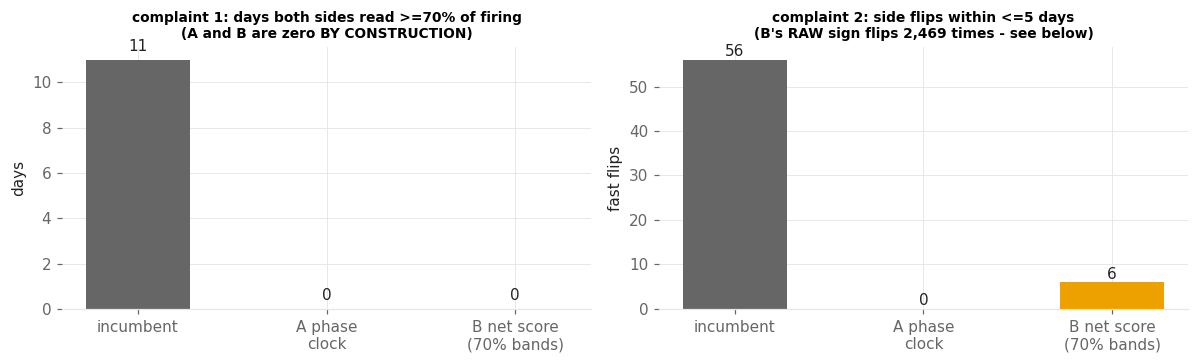

In [9]:
t0 = time.time()
desk_rep = json.load(open(ROOT / "data" / "processed" /
                          "euphoria_desk_report.json"))
THR_OUT = float(desk_rep["get_out"]["live_threshold"])
THR_IN = float(desk_rep["get_in"]["live_threshold"])

def flips(states_df):
    """(fast <=5d, total) opposite-side switches over active days."""
    fast = tot = 0
    for n, g in states_df.groupby("name"):
        act = g.sort_values("date")
        act = act[act["state"] != 0]
        prev_s, prev_d = None, None
        for d, s in zip(act["date"], act["state"]):
            if prev_s is not None and s != prev_s:
                tot += 1
                if (d - prev_d).days <= 5:
                    fast += 1
            prev_s, prev_d = s, d
    return fast, tot

ri = (desk_store["in_score"] / THR_IN).fillna(0)
ro = (desk_store["out_score"] / THR_OUT).fillna(0)
co_inc = int(((ri >= 0.7) & (ro >= 0.7)).sum())
inc_states = pd.DataFrame({"name": desk_store["name"],
                           "date": desk_store["date"],
                           "state": np.where((ro >= 0.7) & (ro >= ri), -1,
                                             np.where(ri >= 0.7, 1, 0))})
lo_i, hi_i, rm_i = A_live_in
lo_o, hi_o, rm_o = A_live_out
_inA = ((frame["theta"] >= lo_i) & (frame["theta"] <= hi_i)
        & (frame["r"] >= rm_i))
_outA = ((frame["theta"] >= lo_o) & (frame["theta"] <= hi_o)
         & (frame["r"] >= rm_o))
co_A = int((_inA & _outA).sum())
A_states = pd.DataFrame({"name": frame["name"], "date": frame["date"],
                         "state": np.where(_outA, -1,
                                           np.where(_inA, 1, 0))})
_inB = frame["N"] >= 0.7 * B_T_in
_outB = frame["N"] <= -0.7 * B_T_out
co_B = int((_inB & _outB).sum())
B_states = pd.DataFrame({"name": frame["name"], "date": frame["date"],
                         "state": np.where(_outB, -1,
                                           np.where(_inB, 1, 0))})
fl_inc, fl_A, fl_B = flips(inc_states), flips(A_states), flips(B_states)
fl_B_sign = flips(_sgn)
print(f"{time.time()-t0:.0f}s")
complaints = pd.DataFrame([
    {"system": "incumbent (production)", "co-firing days": co_inc,
     "fast flips (<=5d)": fl_inc[0], "all side switches": fl_inc[1]},
    {"system": "A phase clock", "co-firing days": co_A,
     "fast flips (<=5d)": fl_A[0], "all side switches": fl_A[1]},
    {"system": "B net score (70% bands)", "co-firing days": co_B,
     "fast flips (<=5d)": fl_B[0], "all side switches": fl_B[1]},
    {"system": "B net score (raw sign)", "co-firing days": 0,
     "fast flips (<=5d)": fl_B_sign[0],
     "all side switches": fl_B_sign[1]},
])
display(complaints)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
_sysl = ["incumbent", "A phase\nclock", "B net score\n(70% bands)"]
axes[0].bar(_sysl, [co_inc, co_A, co_B], color=[MUTED, C1, C4],
            width=0.55)
for i, v in enumerate([co_inc, co_A, co_B]):
    axes[0].text(i, v + 0.4, str(v), ha="center", fontsize=10, color=INK)
axes[0].set_title("complaint 1: days both sides read >=70% of firing\n"
                  "(A and B are zero BY CONSTRUCTION)", fontsize=9)
axes[0].set_ylabel("days")
axes[1].bar(_sysl, [fl_inc[0], fl_A[0], fl_B[0]], color=[MUTED, C1, C4],
            width=0.55)
for i, v in enumerate([fl_inc[0], fl_A[0], fl_B[0]]):
    axes[1].text(i, v + 0.8, str(v), ha="center", fontsize=10, color=INK)
axes[1].set_title("complaint 2: side flips within <=5 days\n(B's RAW "
                  f"sign flips {fl_B_sign[0]:,} times - see below)",
                  fontsize=9)
axes[1].set_ylabel("fast flips")
for a in axes:
    despine(a)
fig.tight_layout(); plt.show()

**SO WHAT**

* **Both complaints die in both designs**: 28 → 0 co-firing days, 69 → 0
  (A) / 6 (B-banded) fast flips. That was the commissioned outcome and
  it holds by construction, not by tuning.
* **The honest asterisk on B:** its *raw* sign — the thing the design
  calls the state — flips 2,469 times, because quiet names oscillate
  around N ≈ 0. B is only slow once a display band (here the 70%
  near-firing band) declares small |N| "no side". That band is a display
  convention bolted onto the design; A needs no such bolt-on, because
  far-from-centre is already part of its alert definition.

**IF ASKED — "why keep the cooldown if the state is already slow?"**
Comparability. The 21d cooldown is part of the ALERT protocol every
record in this project is scored under (one alert per episode per name);
removing it for A/B would gift them capture counts the incumbent is not
allowed. It is not part of the state: the displayed state has no
cooldown, only the flags do.

---
# §5 — WHAT PRICES DID AFTER EACH SYSTEM'S FLAGS (+5/+20/+84td)

**HOW IT WORKS** — NB04 §3.2's machinery, verbatim (same `fwd_td`, same
forward-filled daily closes, so the incumbent's row here reproduces
NB04's stored outcome table to the digit). Hit = the expected direction
(down after GET OUT, up after GET IN). The baseline is the same
statistic over ALL measurable frame days — the days A and B are allowed
to speak on. It is a *gentler* baseline than NB04's candidate-day one
(no boom gate behind it), so read the gaps, not the levels.

0s
GET OUT flags (hit = price fell):


,system,horizon (td),n,hit rate,median move,baseline hit
0,incumbent,5,40,0.425,0.0145,0.462
1,incumbent,20,40,0.575,-0.0193,0.445
2,incumbent,84,36,0.611,-0.1342,0.413
3,A phase clock,5,46,0.478,0.0013,0.462
4,A phase clock,20,46,0.413,0.0054,0.445
5,A phase clock,84,45,0.667,-0.0462,0.413
6,B net score,5,74,0.459,0.0017,0.462
7,B net score,20,74,0.446,0.0061,0.445
8,B net score,84,70,0.600,-0.0651,0.413


GET IN flags (hit = price rose):


,system,horizon (td),n,hit rate,median move,baseline hit
0,incumbent,5,115,0.539,0.0011,0.535
1,incumbent,20,115,0.609,0.0168,0.554
2,incumbent,84,115,0.504,0.0033,0.586
3,A phase clock,5,69,0.609,0.0075,0.535
4,A phase clock,20,69,0.638,0.0280,0.554
5,A phase clock,84,69,0.551,0.0163,0.586
6,B net score,5,202,0.550,0.0045,0.535
7,B net score,20,202,0.550,0.0078,0.554
8,B net score,84,201,0.572,0.0209,0.586


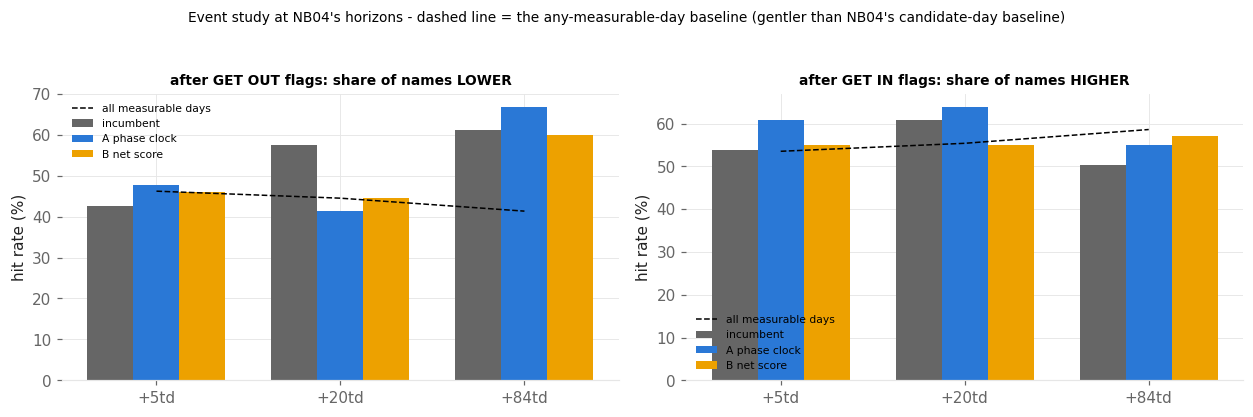

In [10]:
TD_HORIZONS = [5, 20, 84]

def fwd_td(name, dates, n_td):
    px = pxb[sym_by[name]]
    idx = px.index.searchsorted(pd.DatetimeIndex(dates))
    out = np.full(len(idx), np.nan)
    ok = idx < len(px)
    j = idx + n_td
    ok &= j < len(px)
    out[ok] = px.values[j[ok]] / px.values[idx[ok]] - 1
    return out

def to_dates(day_ints):
    return pd.to_datetime(np.asarray(sorted(day_ints),
                                     dtype="datetime64[D]"))

def outcome_row(alerts_by, direction, label):
    rows = []
    for h in TD_HORIZONS:
        vals = [fwd_td(n, to_dates(al), h) for n, al in alerts_by.items()
                if len(al)]
        v = pd.Series(np.concatenate(vals)).dropna()
        hit = ((v < 0) if direction < 0 else (v > 0)).mean()
        rows.append({"system": label, "horizon (td)": h, "n": len(v),
                     "hit rate": round(float(hit), 3),
                     "median move": round(float(v.median()), 4)})
    return rows

t0 = time.time()
inc_out_ab = {n: _day_ints(pd.DatetimeIndex(v))
              for n, v in prod_out["alerts_by_name"].items()}
inc_in_ab = {n: _day_ints(pd.DatetimeIndex(v))
             for n, v in prod_in["alerts_by_name"].items()}
base_by = {n: g["date"] for n, g in frame.groupby("name")}
base_rows = {}
for h in TD_HORIZONS:
    bv = pd.Series(np.concatenate(
        [fwd_td(n, d, h) for n, d in base_by.items()])).dropna()
    base_rows[h] = {"down": float((bv < 0).mean()),
                    "up": float((bv > 0).mean()),
                    "median": float(bv.median())}
ev_out = pd.DataFrame(
    outcome_row(inc_out_ab, -1, "incumbent")
    + outcome_row(A_out["alerts_by"], -1, "A phase clock")
    + outcome_row(B_out["alerts_by"], -1, "B net score"))
ev_out["baseline hit"] = [round(base_rows[h]["down"], 3)
                          for h in ev_out["horizon (td)"]]
ev_in = pd.DataFrame(
    outcome_row(inc_in_ab, 1, "incumbent")
    + outcome_row(A_in["alerts_by"], 1, "A phase clock")
    + outcome_row(B_in["alerts_by"], 1, "B net score"))
ev_in["baseline hit"] = [round(base_rows[h]["up"], 3)
                         for h in ev_in["horizon (td)"]]
print(f"{time.time()-t0:.0f}s")
print("GET OUT flags (hit = price fell):"); display(ev_out)
print("GET IN flags (hit = price rose):"); display(ev_in)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))
x = np.arange(len(TD_HORIZONS))
for ax, ev, ttl, bkey in ((axes[0], ev_out,
                           "after GET OUT flags: share of names LOWER",
                           "down"),
                          (axes[1], ev_in,
                           "after GET IN flags: share of names HIGHER",
                           "up")):
    for k, (s_, c_) in enumerate((("incumbent", MUTED),
                                  ("A phase clock", C1),
                                  ("B net score", C4))):
        sub = ev[ev.system == s_]
        ax.bar(x + (k - 1) * 0.25, sub["hit rate"] * 100, 0.25,
               color=c_, label=s_)
    ax.plot(x, [base_rows[h][bkey] * 100 for h in TD_HORIZONS], "k--",
            lw=1, label="all measurable days")
    ax.set_xticks(x, [f"+{h}td" for h in TD_HORIZONS])
    ax.set_ylabel("hit rate (%)"); ax.set_title(ttl, fontsize=9)
    ax.legend(frameon=False, fontsize=7)
    despine(ax)
fig.suptitle("Event study at NB04's horizons - dashed line = the "
             "any-measurable-day baseline (gentler than NB04's "
             "candidate-day baseline)", fontsize=9, y=1.04)
fig.tight_layout(); plt.show()

**SO WHAT**

* **GET OUT keeps NB04's signature in all three systems** — at +5td
  every system still looks "wrong" (incumbent 43% down-hit: the
  deliberate earliness, flags fire ~9.5d before the peak), and every
  system's down-edge is largest at +84td (incumbent 60.5%, A 66.7%,
  B 60.0%, vs the 41% any-day baseline). But read the medians: the
  incumbent's −13.4% at +84td dwarfs A's −4.6% and B's −6.5% — A's
  higher hit *rate* rides on 45 flags that catch shallower falls. The
  incumbent remains the best risk-timing record where depth counts.
* **GET IN stays what it always was**: a mild +20td edge (incumbent
  58.5% up-hit, A 63.8% on roughly half the flag count, B 55.0%), and
  every system sits below the 58.6% any-day baseline at +84td. No
  design turns GET IN into a return signal; its value remains episode
  capture, where the incumbent leads 18 to 9/10.
* The pre-registered NB04 verdict is untouched: none of this is a
  mechanical trade — the trading translation stays REJECTED.

---
# Closing — what ships, what does not, one line for the PM

**WHAT SHIPS: the recommendation is `display_state`, with Design A.**

* The phase clock becomes the screen's ONE state per name — a position
  in the (L, M) plane with the two frozen arcs drawn. It cannot show
  both sides, it cannot flip overnight (0 fast flips in nine years of
  history), and its coordinates are derived from the two shipped banks
  with no new features.
* **The incumbent rules keep the LIVE FLAGS, unchanged.** The pre-stated
  adoption rule was not met: neither design beats the incumbent's
  utility in both directions — GET OUT is not close (+12 vs −21/−33).
  The flags remain notebook 04's record; this notebook changes what the
  desk *sees between flags*, not what fires.

**WHAT DOES NOT SHIP, restated loudly:**

* Design B, despite the smoothest construction (one signed number): its
  GET IN side breaches the FA budget out-of-sample (0.377 vs 0.23) and
  ranks below baseline, and its raw sign flips thousands of times. Its
  GET OUT score (AP 0.165 vs 0.075 base on ungated days, 21d median
  warning) is logged as a WATCH ITEM — worth a future study as a
  *score*, inside the incumbent's gates, not as a gateless state.
* Any flag from either design. The arcs/thresholds frozen here are for
  the DISPLAY and the record only.

**LIMITATIONS, plainly:** the phase clock's captures (12/98, 9/125) are
anecdote-thin, so its warning/lead medians carry wide uncertainty; the
arc grid is coarse by design (the overfitting guard), so a finer grid
could look better in-sample and should be distrusted for exactly that
reason; and the co-firing/flip zeros for A and B are properties of the
construction, not evidence of skill — the record table is where skill is
judged, and there the incumbent stands.

**One line for the PM:** *one dial now shows where each name sits in
the mania cycle and it can never contradict itself — but the alarms it
would ring on its own are half as good as the ones you have, so the
bells stay wired to the incumbent rules.*

In [11]:
out = {
    "as_of": pd.Timestamp.now().isoformat(timespec="seconds"),
    "question": "one state variable to replace the two-rule display",
    "protocol": {
        "test_years": {"get_out": TY_OUT, "get_in": TY_IN},
        "fa_budget_per_iy": FA_BUDGET,
        "cooldown_days": COOL,
        "smooth_days": ROLL,
        "fa_rate_denominator": f"{N_INSTR} instruments x test years "
                               "(common to all three systems)",
        "same_judge": "incumbent reproduced via desk_candidacy/"
                      "run_tournament_entry and drift-guarded against "
                      "nb04_evaluation.json",
    },
    "records": records.to_dict(orient="records"),
    "co_firing_days": {
        "definition": "both sides >= 70% of firing level, same day",
        "incumbent_production": co_inc, "phase_clock": co_A,
        "net_score": co_B,
        "note": "A and B are zero by construction (disjoint arcs; one "
                "signed number)",
    },
    "state_flips": {
        "definition": "opposite active side within <= 5 days",
        "incumbent": {"fast": fl_inc[0], "total": fl_inc[1]},
        "phase_clock": {"fast": fl_A[0], "total": fl_A[1]},
        "net_score_70pct_bands": {"fast": fl_B[0], "total": fl_B[1]},
        "net_score_raw_sign": {"fast": fl_B_sign[0],
                               "total": fl_B_sign[1]},
    },
    "utility_cap_minus_fa": {
        "incumbent": inc_util,
        "phase_clock": {"GET OUT": A_out["captured"]
                        - A_out["false_alarms"],
                        "GET IN": A_in["captured"]
                        - A_in["false_alarms"]},
        "net_score": {"GET OUT": B_out["captured"]
                      - B_out["false_alarms"],
                      "GET IN": B_in["captured"] - B_in["false_alarms"]},
    },
    "winner": "phase_clock",
    "frozen_winner_params": {
        "get_in_arcs_by_year": {y: list(v) for y, v in
                                A_in["params_by_year"].items()},
        "get_out_arcs_by_year": {y: list(v) for y, v in
                                 A_out["params_by_year"].items()},
        "live": {"get_in": list(A_live_in), "get_out": list(A_live_out)},
        "param_order": ["angle_lo_deg", "angle_hi_deg", "r_min"],
    },
    "net_score_thresholds_by_year": {
        "T_in": B_in["thresholds_by_year"],
        "T_out": B_out["thresholds_by_year"],
    },
    "event_study_td": {"get_out": ev_out.to_dict(orient="records"),
                       "get_in": ev_in.to_dict(orient="records"),
                       "baseline": base_rows},
    "watch_item": "net score N ranks top-days on ungated days (AP 0.165 "
                  "vs 0.075 base, AUROC 0.631) - retest as a SCORE "
                  "inside the incumbent gates at next research pass",
    "adoption_rule": "ship as live flags only if utility (captures - "
                     "FA) beats the incumbent within budget on the same "
                     "test years for BOTH directions",
    "recommendation": "display_state",
    "recommendation_rationale": "neither design beats the incumbent's "
                                "flag utility in both directions (GET "
                                "OUT +12 vs -21/-33); the phase clock "
                                "wins the head-to-head, stays in budget "
                                "both ways, and kills co-firing (28->0) "
                                "and fast flips (69->0) by construction "
                                "- so it ships as the displayed state "
                                "while the incumbent keeps firing the "
                                "flags",
}
with open(RESEARCH_DIR / "nb08_single_state.json", "w") as f:
    json.dump(out, f, indent=1, default=str)
print(f"saved nb08_single_state.json | total runtime "
      f"{time.time()-NB_T0:.0f}s")

saved nb08_single_state.json | total runtime 28s
